In this code we prepared the observational data used for the training, validation and testing of the Convolutional Neural Network. 

The code is divided as follows:
1) HadISST and NCEP NCAR datasets are downloaded and prepared;
2) Standardized SST and SLP anomalies of the Indian and Pacific oceans are computed for training, validation and testing;
3) The September-November (SON) Dipole Index (DI) is computed and standardized;
4) The results are saved in a file pickle.

# Import the libraries

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import dill

# FUNCTIONS

## Regional selection functions

In [ ]:
def di_west_east(dataset):
    # Compute mean SST in west and east areas to compute the Dipole Index.

    di_west = dataset.sel(lon=slice(50,70),lat=slice(10,-10)).mean(dim=('lon','lat'))
    di_east = dataset.sel(lon=slice(90,110),lat=slice(0,-10)).mean(dim=('lon','lat'))
    return di_west, di_east

def input_indian_pacific(dataset):
    # Select the Indian Ocean domain and the Pacific Ocean domain as input for the CNN training and validation.

    indian_pacific_east = dataset.sel(lon=slice(30,180),lat=slice(25,-45))
    indian_pacific_west = dataset.sel(lon=slice(-180,-70),lat=slice(25,-45))
    indian_pacific_west_new = indian_pacific_west.assign_coords(lon=(np.where(indian_pacific_west.lon < 0, indian_pacific_west.lon + 360, indian_pacific_west.lon))) # negative values become positive
    indian_pacific = xr.concat([indian_pacific_west_new, indian_pacific_east], dim="lon")
    indian_pacific = indian_pacific.sortby("lon")  # sort longitudes from 30° to 290°
    return indian_pacific

## Standardization function

In [ ]:
def standardization(dataset,dataset_mean_clim,dataset_std_clim):
    # Compute the standardization with respect to the training climatology
    dataset_standardized = (dataset - dataset_mean_clim) / dataset_std_clim
    return dataset_standardized

## Climatology and anomaly functions

In [ ]:
def compute_seasonal_mean(dataset, months, year_start, year_end):
    # Compute seasonal mean for given months and years.
    dataset = dataset.sel(time=slice(year_start, year_end))
    seasonal_mean = dataset.sel(time=dataset["time.month"].isin(months)).groupby("time.year").mean("time").rename({"year": "time"})
    return seasonal_mean

## Build a dictionary with anomaly, climatology, yearly values for training, validation and testing

In [ ]:
# Build a dictionary with climatology, anomaly and standardized anomaly for each month and each split (training, validation, testing).
# Standardization is computed with respect to the training climatology mean and std.
def build_dataset_dic(dataset, months_list, months_name, key_argument_string,train_val_test_splits, year_start_climatology, year_end_climatology):

    dic = {}
    for month, name in zip(months_list, months_name):
        key = f'{name} ({key_argument_string})'
        dic[key] = {}
        yearly_clim = compute_seasonal_mean(dataset, month, year_start_climatology, year_end_climatology)
        climatology = yearly_clim.mean("time")
        dic[key]['climatology'] = climatology

        # Mean and std computed on training only (for standardization)
        training_anomaly = yearly_clim - climatology
        training_mean = training_anomaly.mean(dim='time')
        training_std = training_anomaly.std(dim='time')

        for split, (y_start, y_end) in train_val_test_splits.items():
            yearly_sst = compute_seasonal_mean(dataset, month, y_start, y_end)
            anomaly = yearly_sst - climatology
            
            dic[key][f'yearly sst {split}'] = yearly_sst
            dic[key][f'anomaly {split}'] = anomaly
            dic[key][f'standardized anomaly {split}'] = standardization(anomaly,training_mean,training_std)
    return dic

# Data for the TRAINING: HadISST (SST) and NCEP NCAR (SLP) 1948-2022

## Open and decode a dataset from a file by using the xarray library for both the HadISST and NCEP NCAR datasets

In [ ]:
# Resolution of 2°x2°
hadisst_sst = xr.open_dataset(r"/mnt/c/Users/sara.beltrami9/OneDrive - Alma Mater Studiorum Università di Bologna/my_project/codici/albatross_project/HadISST_sst_remapcon2.nc")
ncep_ncar_slp = xr.open_dataset(r"/mnt/c/Users/sara.beltrami9/OneDrive - Alma Mater Studiorum Università di Bologna/my_project/codici/albatross_project/ncep_ncar_slp_1948_2022_remapcon2.nc")

## PREPARE THE DATA

### HadISST: Select the Dipole Index domain and the Indian/Pacific ocean input domain for the SST and SLP

In [8]:
#HadISST SST
#Select the Dipole Index domain
hadisst_sst_di_areas = di_west_east(hadisst_sst['sst'])
#Select the Indian/Pacific ocean input domain
hadisst_sst_input_indian_pacific = input_indian_pacific(hadisst_sst['sst'])

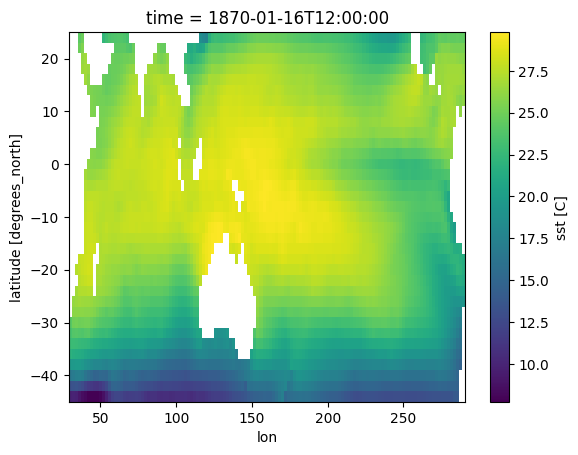

In [9]:
hadisst_sst_input_indian_pacific[0,:,:].plot()

### NCEP NCAR: Select the Indian/Pacific ocean input domain for the SST and SLP

In [10]:
#NCEP NCAR SLP
#The dataset has each month repeated, so it is necessary to drop duplicates
ncep_ncar_slp = ncep_ncar_slp.drop_duplicates(dim='time')

In [11]:
#Select the Dipole Index domain
ncep_ncar_slp_input_indian_pacific = input_indian_pacific(ncep_ncar_slp['slp'])

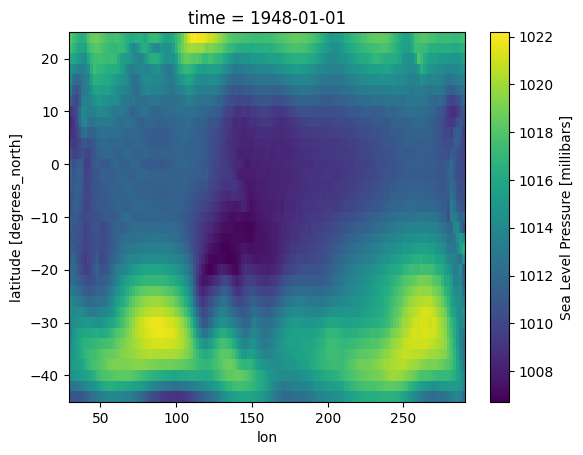

In [12]:
ncep_ncar_slp_input_indian_pacific[0,:,:].plot()

## Define the January-August months for the standardized HadISST SST and NCEP NCAR SLP

In [13]:
months_list = [1,2,3,4,5,6,7,8]
months_name = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG']

In [ ]:
# Divide the years in training, validation, testing
# The testing period precedes the validation period to avoid that validation data are influenced by training data.
train_val_test_splits = {
    'training': ("1948", "2000"),
    'validation': ("2008", "2022"),
    'testing': ("2001", "2007"),
}

In [ ]:
# The climatology is computed with respect to the training period
year_start_climatology = "1948"
year_end_climatology = "2000"

### HadISST

In [16]:
hadisst_dic = build_dataset_dic(hadisst_sst_input_indian_pacific, months_list, months_name, 'Indian Pacific oceans',train_val_test_splits, year_start_climatology, year_end_climatology)

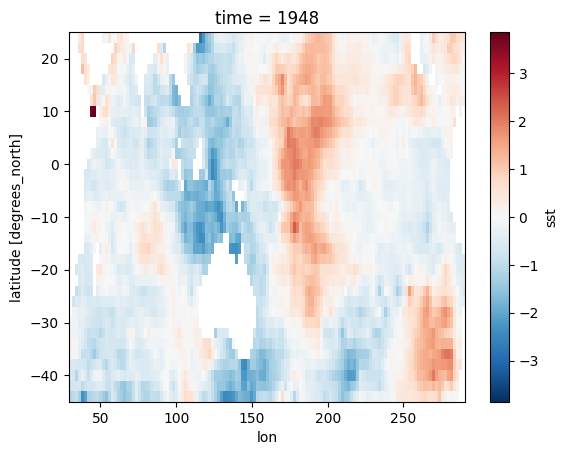

In [17]:
hadisst_dic['JUN (Indian Pacific oceans)']['standardized anomaly training'][0,:,:].plot()

### NCEP NCAR

In [18]:
ncep_ncar_dic = build_dataset_dic(ncep_ncar_slp_input_indian_pacific, months_list, months_name, 'Indian Pacific oceans',train_val_test_splits, year_start_climatology, year_end_climatology)

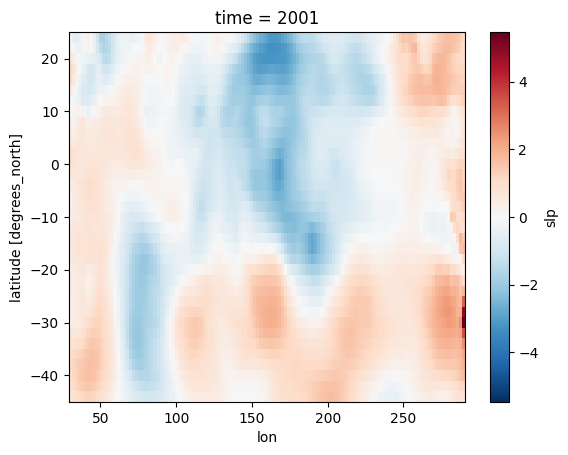

In [19]:
ncep_ncar_dic['JUN (Indian Pacific oceans)']['standardized anomaly testing'][0,:,:].plot()

## Define the Dipole Index for HadISST during September-November

### HadISST

In [ ]:
# Dipole index area is computed as SSTs of the western region minus the SSTs of the eastern region
di_dataset = hadisst_sst_di_areas[0] - hadisst_sst_di_areas[1]

key_son = 'SON (di west-east)'
hadisst_dic[key_son] = {}

for split, (y_start, y_end) in train_val_test_splits.items():
    # Monthly means of SON season
    son_anomaly = compute_seasonal_mean(di_dataset,[9,10,11], y_start, y_end)
    climatology = compute_seasonal_mean(di_dataset,[9,10,11], year_start_climatology, year_end_climatology).mean('time')
    anomaly = son_anomaly - climatology
    hadisst_dic[key_son][f'anomaly {split}'] = anomaly

# Standard deviation on training
training_std = hadisst_dic[key_son]['anomaly training'].std(dim='time')

# Normalize the DI by the training standard deviation to obtain a dimensionless index
for split in train_val_test_splits:
    hadisst_dic[key_son][f'dipole index {split}'] = hadisst_dic[key_son][f'anomaly {split}'] / training_std

# Upload in a file pickle

In [21]:
with open('cnn_obs.pkl', 'wb') as file:
    dill.dump(hadisst_dic, file)
    dill.dump(ncep_ncar_dic, file)